In [1]:
import pandas as pd
import matplotlib.pyplot as pit

# Đọc file
df = pd.read_csv('../api/used_cars.csv')
df


ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Số lượng giá trị null

df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [ ]:
# Xóa các hàng có các giá trị là null hoặc không có giá trị

df = df.dropna(axis=0)

In [ ]:
# Kiểm tra lại các giá trị null hoặc không có giá trị

df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [ ]:
# Hiển thị các giá trị cơ bản trong dataframe
df.describe()

,model_year
count,3269.000000
mean,2014.601407
std,6.152181
min,1974.000000
25%,2011.000000
50%,2016.000000
75%,2019.000000
max,2024.000000


In [ ]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"


In [ ]:
# Xử lý giá tiền của xe từ chuỗi thành số

df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

# Xử lý số dặm xe đã đi

df['milage'] = (
    df['milage']
    .str.replace(',', '', regex=False)
    .str.replace('mi.', '', regex=False)
    .astype(int)
)

df['milage']



0        51000
1        34742
3        88900
6        84000
7       242000
         ...  
4003     53705
4004       714
4005     10900
4007     33000
4008     43000
Name: milage, Length: 3269, dtype: int64

In [ ]:
# Hiển thị các giá trị cơ bản trong dataframe
df.describe()

,model_year,milage,price
count,3269.000000,3269.000000,3.269000e+03
mean,2014.601407,72126.951973,4.124113e+04
std,6.152181,53387.413623,8.304604e+04
min,1974.000000,100.000000,2.000000e+03
25%,2011.000000,30450.000000,1.550000e+04
50%,2016.000000,62930.000000,2.800000e+04
75%,2019.000000,102750.000000,4.650000e+04
max,2024.000000,405000.000000,2.954083e+06


Index(['Ford', 'BMW', 'Mercedes-Benz', 'Chevrolet', 'Toyota'], dtype='str', name='brand')


Text(0.5, 1.0, 'Biểu đồ số lượng xe các năm của các hãng top đầu')

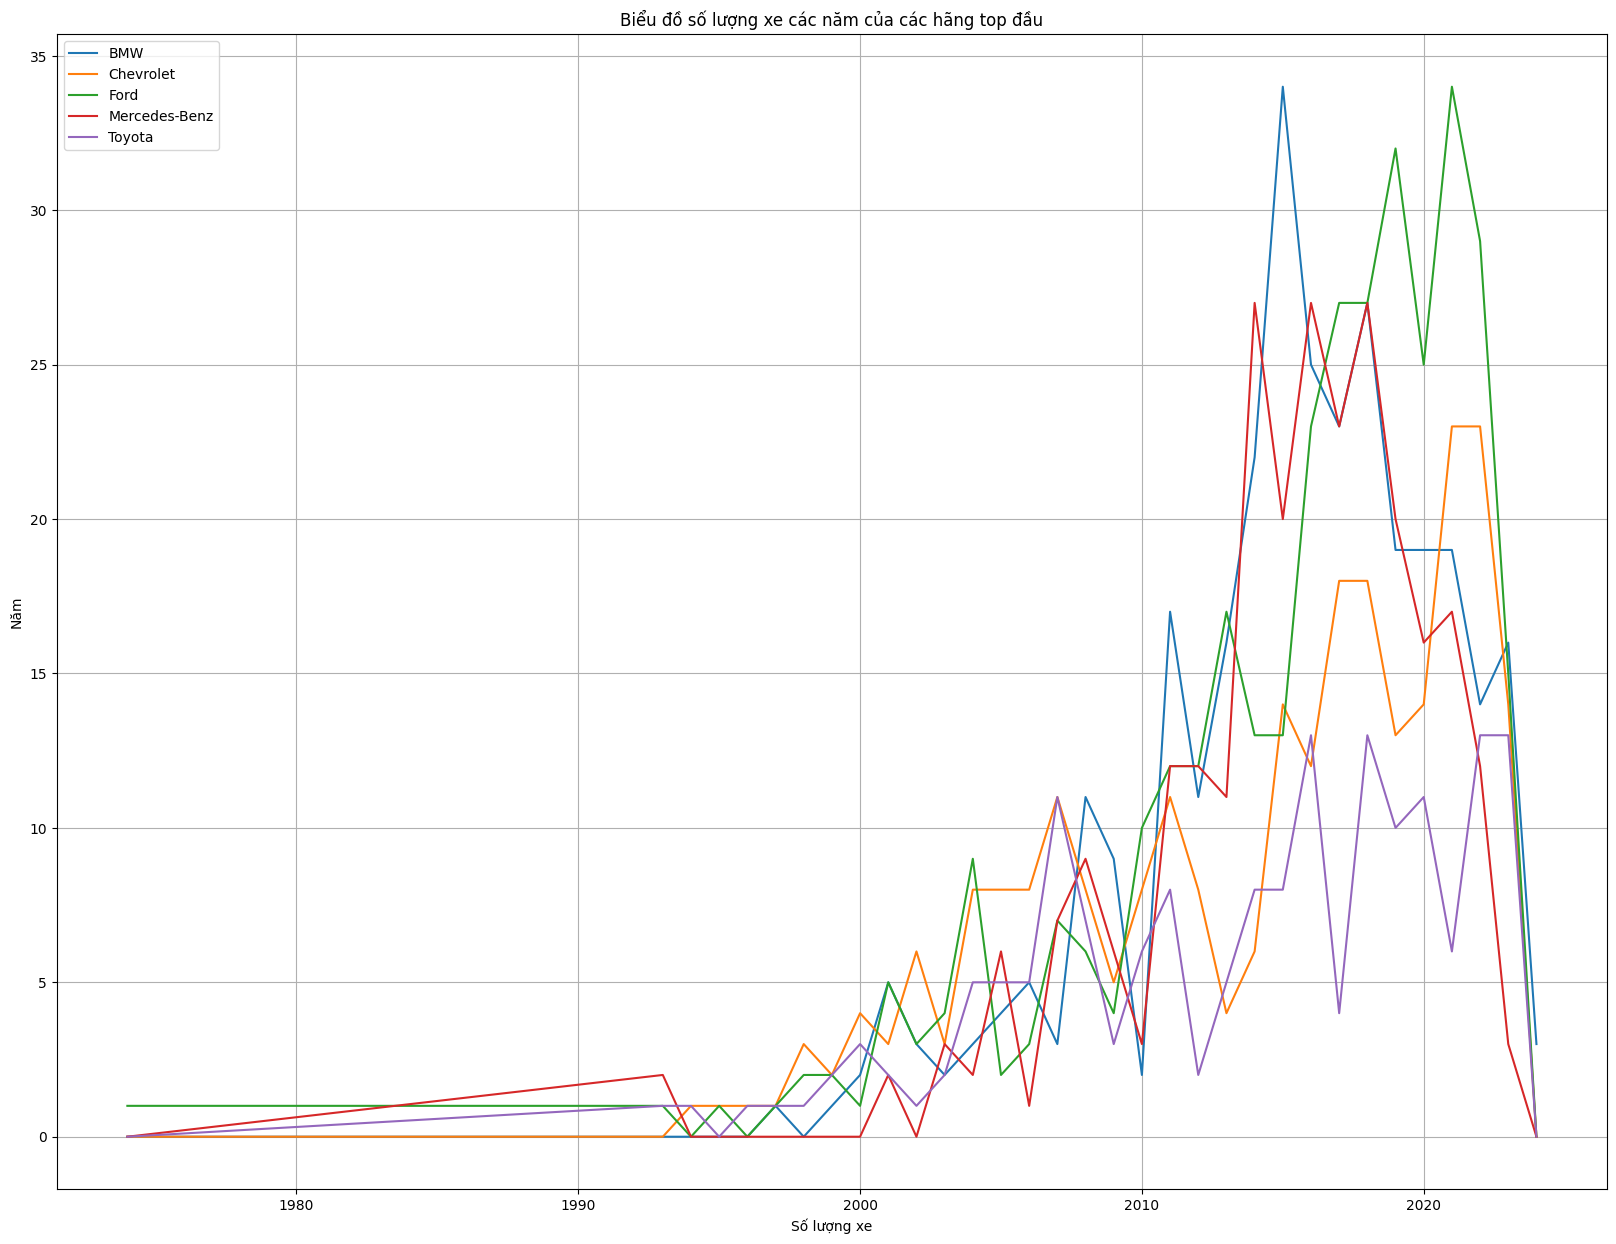

In [ ]:
# Biều đồ đường: Dùng để biểu diễn tổng số xe của hãng đó trong các năm

top_brand = df['brand'].value_counts().head().index

print(top_brand)
df_top_brand = df[df['brand'].isin(top_brand)]
pivot_df = df_top_brand.pivot_table(index='model_year', columns='brand', values='model', aggfunc='count', fill_value=0)

pit.figure(figsize=(20, 15))
for brand in pivot_df.columns:
    pit.plot(pivot_df.index, pivot_df[brand], label=brand)

pit.xlabel('Số lượng xe')
pit.ylabel('Năm')
pit.legend()
pit.grid()
pit.title('Biểu đồ số lượng xe các năm của các hãng top đầu')

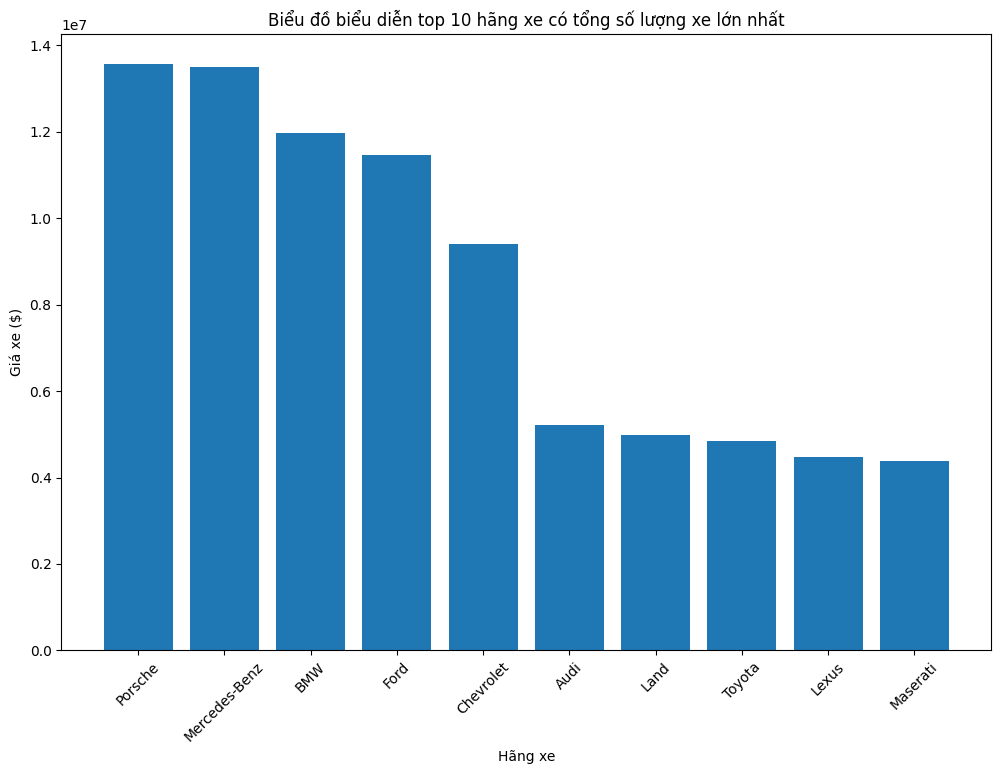

In [ ]:
# Biểu đồ cột: Dùng để biểu diễn top 10 hãng xe có tổng số lượng xe lớn nhất

df_sum_brand = df[['brand', 'price']].groupby('brand').sum()
df_sum_brand = df_sum_brand.sort_values(by='price', ascending=False).head(10)
df_sum_brand

pit.figure(figsize=(12, 8))
pit.bar(x=df_sum_brand.index, height=df_sum_brand['price'])
pit.xticks(rotation=45)
pit.title('Biểu đồ biểu diễn top 10 hãng xe có tổng số lượng xe lớn nhất')
pit.xlabel('Hãng xe')
pit.ylabel('Giá xe ($)')
pit.show()


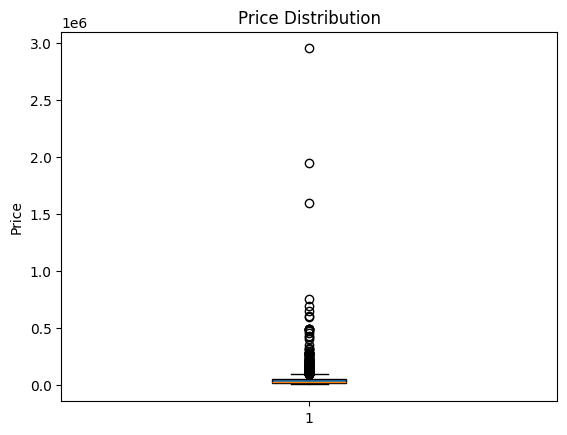

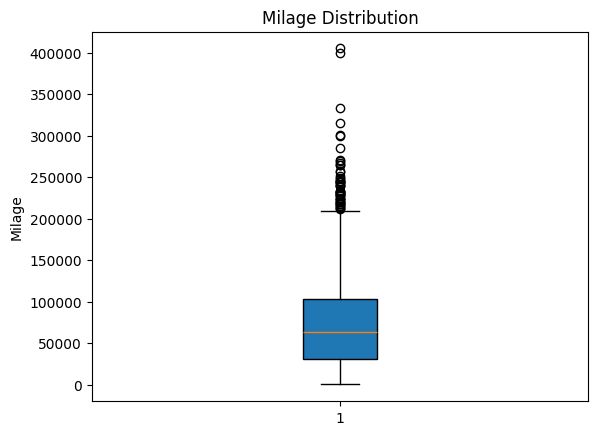

In [ ]:
# Biều đồ biểu thị giá trị ngoại lai (Box plot)

pit.boxplot(df['price'], patch_artist=True)
pit.title("Price Distribution")
pit.ylabel("Price")
pit.show()

pit.boxplot(df['milage'], patch_artist=True)
pit.title("Milage Distribution")
pit.ylabel("Milage")
pit.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Chuyển đổi nhiên liệu và màu ngoại/nội thất thành dạng để phân tích

    # Label encoding


le = LabelEncoder()

# Nhiên liệui
df['fuel_type'] = le.fit_transform(df['fuel_type'])

# Màu ngoại thất
df['ext_col'] = le.fit_transform(df['ext_col'])

# Màu nội thất
df['int_col'] = le.fit_transform(df['int_col'])

pd.get_dummies(df, columns=['int_col'])



,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,accident,clean_title,...,int_col_64,int_col_65,int_col_66,int_col_67,int_col_68,int_col_69,int_col_70,int_col_71,int_col_72,int_col_73
0,Ford,Utility Police Interceptor Base,2013,51000,1,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,8,At least 1 accident or damage reported,Yes,...,False,False,False,False,False,False,False,False,False,False
1,Hyundai,Palisade SEL,2021,34742,2,3.8L V6 24V GDI DOHC,8-Speed Automatic,69,At least 1 accident or damage reported,Yes,...,False,False,False,False,False,False,False,False,False,False
3,INFINITI,Q50 Hybrid Sport,2015,88900,3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,8,None reported,Yes,...,False,False,False,False,False,False,False,False,False,False
6,Audi,S3 2.0T Premium Plus,2017,84000,2,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,14,None reported,Yes,...,False,False,False,False,False,False,False,False,False,False
7,BMW,740 iL,2001,242000,2,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,47,None reported,Yes,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4003,Mercedes-Benz,E-Class E 300 4MATIC,2018,53705,2,241.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,8,At least 1 accident or damage reported,Yes,...,False,False,False,False,False,False,False,False,False,False
4004,Bentley,Continental GT Speed,2023,714,2,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,20,None reported,Yes,...,False,False,False,False,False,False,False,False,False,False
4005,Audi,S4 3.0T Premium Plus,2022,10900,2,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,8,None reported,Yes,...,False,False,False,False,False,False,False,False,False,False
4007,Ford,F-150 Raptor,2020,33000,2,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,14,None reported,Yes,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Biểu đồ biẻu diễn mối quan hệ giữa số dặm đi, số năm sản suát, màu, nhiên liệu và giá xe

